#### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import os

import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from imblearn.combine import SMOTETomek
from sklearn.preprocessing import RobustScaler, MinMaxScaler

#### Import Dataset

In [2]:
dataset_path = '/home/sarantis/Documents/Διπλωματική Εργασία/Milling-Dataset/Dataset/ai4i2020.csv'
milling_df = pd.read_csv(dataset_path)

milling_df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


In [3]:
milling_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [4]:
milling_df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [5]:
milling_df.apply(lambda x: x.nunique())

UDI                        10000
Product ID                 10000
Type                           3
Air temperature [K]           93
Process temperature [K]       82
Rotational speed [rpm]       941
Torque [Nm]                  577
Tool wear [min]              246
Target                         2
Failure Type                   6
dtype: int64

In [6]:
# Drop 'UDI' and 'Product ID' columns
milling_df = milling_df.drop(['UDI', 'Product ID'], axis=1)

milling_df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,M,298.1,308.6,1551,42.8,0,0,No Failure
1,L,298.2,308.7,1408,46.3,3,0,No Failure
2,L,298.1,308.5,1498,49.4,5,0,No Failure
3,L,298.2,308.6,1433,39.5,7,0,No Failure
4,L,298.2,308.7,1408,40.0,9,0,No Failure


In [7]:
milling_df['Failure Type'].value_counts()

Failure Type
No Failure                  9652
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45
Random Failures               18
Name: count, dtype: int64

In [8]:
failure_df = milling_df[milling_df['Target'] == 0]
failure_df['Failure Type'].value_counts()

Failure Type
No Failure         9643
Random Failures      18
Name: count, dtype: int64

In [9]:
failure_df[failure_df['Failure Type'] == 'Random Failures']

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
1221,M,297.0,308.3,1399,46.4,132,0,Random Failures
1302,L,298.6,309.8,1505,45.7,144,0,Random Failures
1748,H,298.4,307.7,1626,31.1,166,0,Random Failures
2072,L,299.6,309.5,1570,35.5,189,0,Random Failures
2559,L,299.3,309.0,1447,50.4,140,0,Random Failures
3065,M,300.1,309.2,1687,27.7,95,0,Random Failures
3452,H,301.6,310.5,1602,32.3,2,0,Random Failures
5471,L,302.7,312.3,1346,61.2,170,0,Random Failures
5489,L,302.6,312.1,1499,35.0,215,0,Random Failures
5495,H,302.9,312.5,1357,55.0,12,0,Random Failures


In [10]:
index_possible_failure = failure_df[failure_df['Failure Type'] == 'Random Failures'].index
milling_df.drop(index_possible_failure, axis=0, inplace=True)

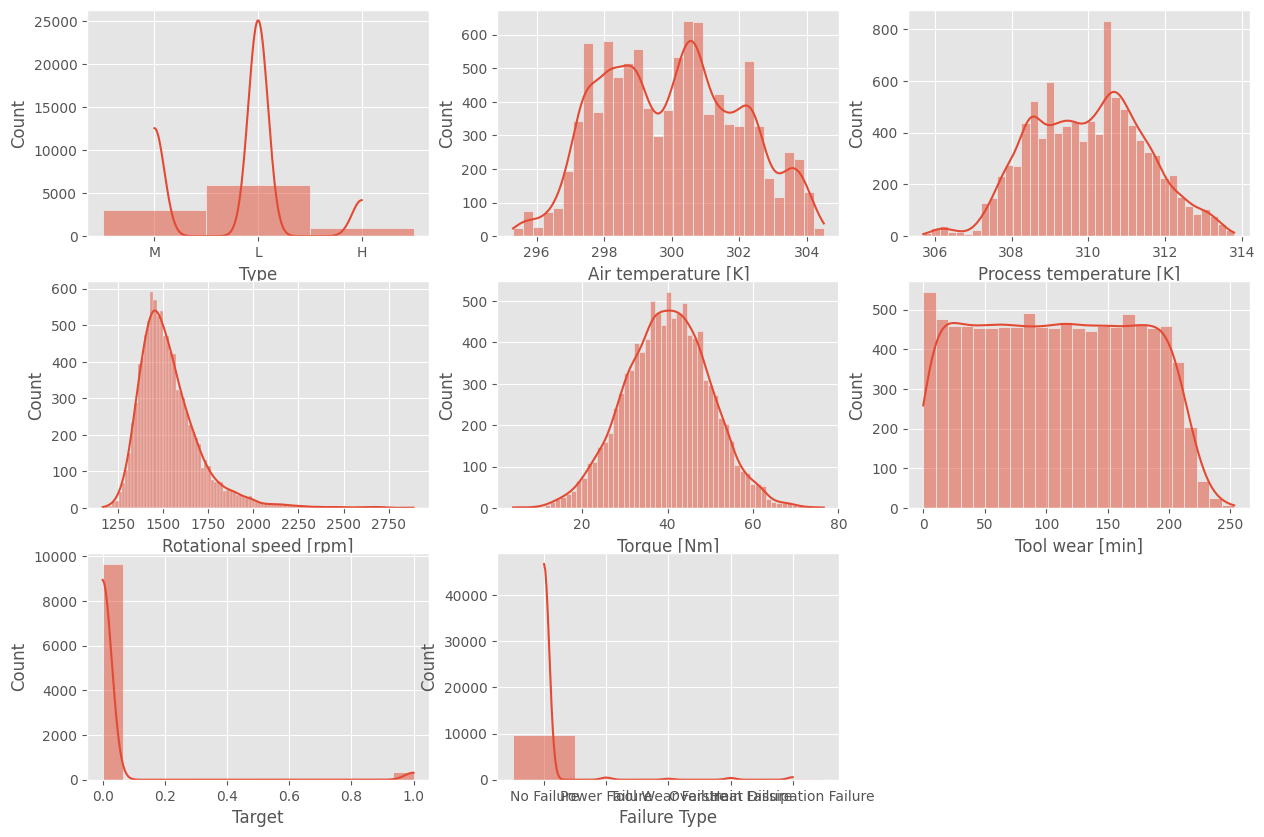

In [11]:
plt.figure(figsize=(15,10))
for i,col in enumerate(milling_df.columns,1):
    plt.subplot(3,3,i)
    sns.histplot(milling_df[col],kde=True)

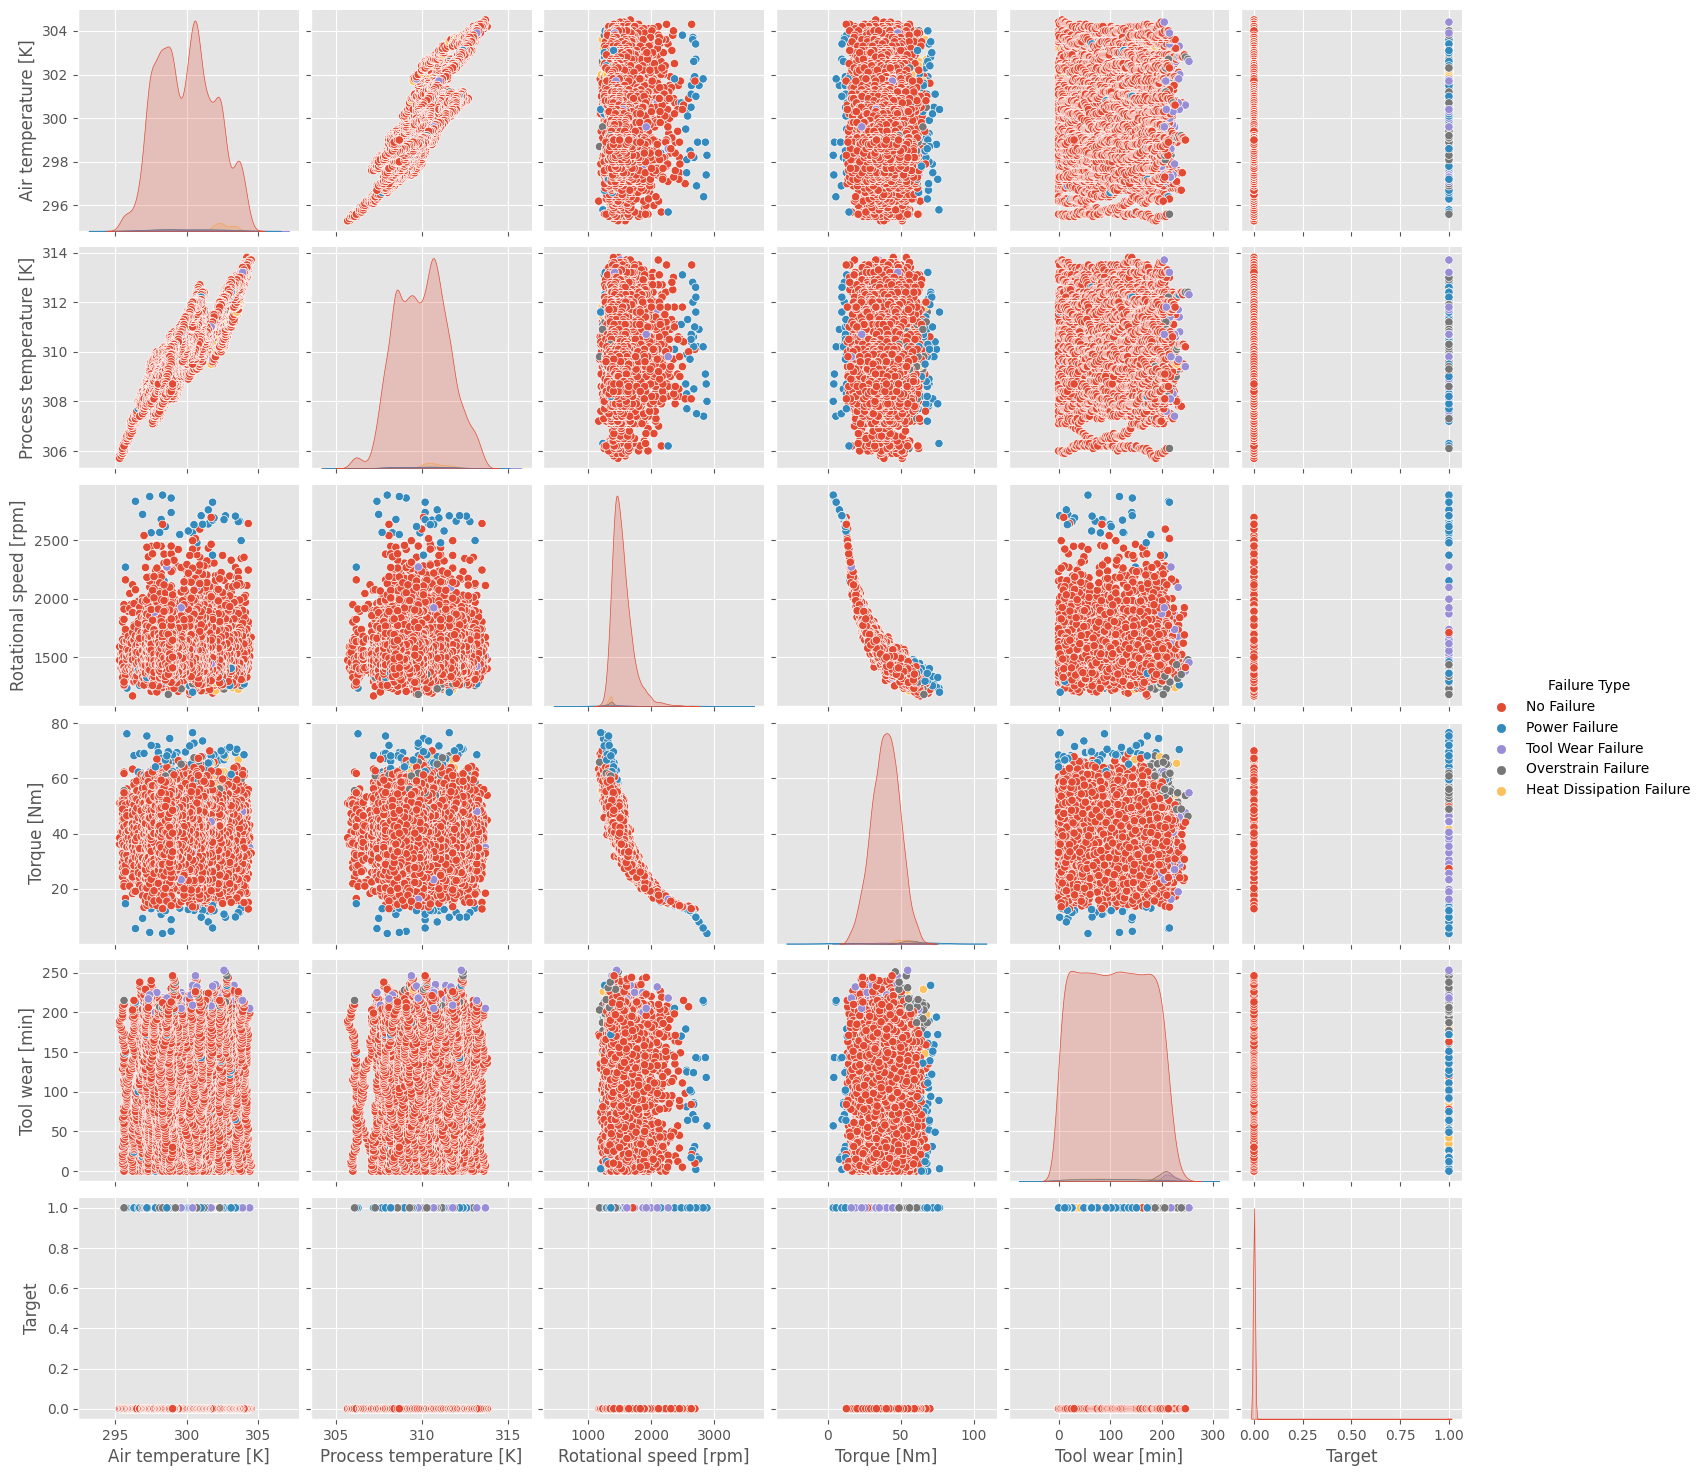

In [12]:
sns.pairplot(milling_df, hue='Failure Type', diag_kind='kde')
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

milling_df['Failure Type'] = le.fit_transform(milling_df['Failure Type'])
failure_type_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping for 'Failure Type':", failure_type_mapping)

milling_df['Type'] = le.fit_transform(milling_df['Type'])
type_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping for 'Type':", type_mapping)

milling_df.head()

Label Mapping for 'Failure Type': {'Heat Dissipation Failure': 0, 'No Failure': 1, 'Overstrain Failure': 2, 'Power Failure': 3, 'Tool Wear Failure': 4}
Label Mapping for 'Type': {'H': 0, 'L': 1, 'M': 2}


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,2,298.1,308.6,1551,42.8,0,0,1
1,1,298.2,308.7,1408,46.3,3,0,1
2,1,298.1,308.5,1498,49.4,5,0,1
3,1,298.2,308.6,1433,39.5,7,0,1
4,1,298.2,308.7,1408,40.0,9,0,1


#### Split the Dataset

In [14]:
X_x = milling_df.drop(['Failure Type', 'Target'], axis=1) 
y = milling_df['Failure Type']          

X_train, X_test, y_train, y_test = train_test_split(X_x, y, test_size=0.5, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4991, 6)
X_test shape: (4991, 6)
y_train shape: (4991,)
y_test shape: (4991,)


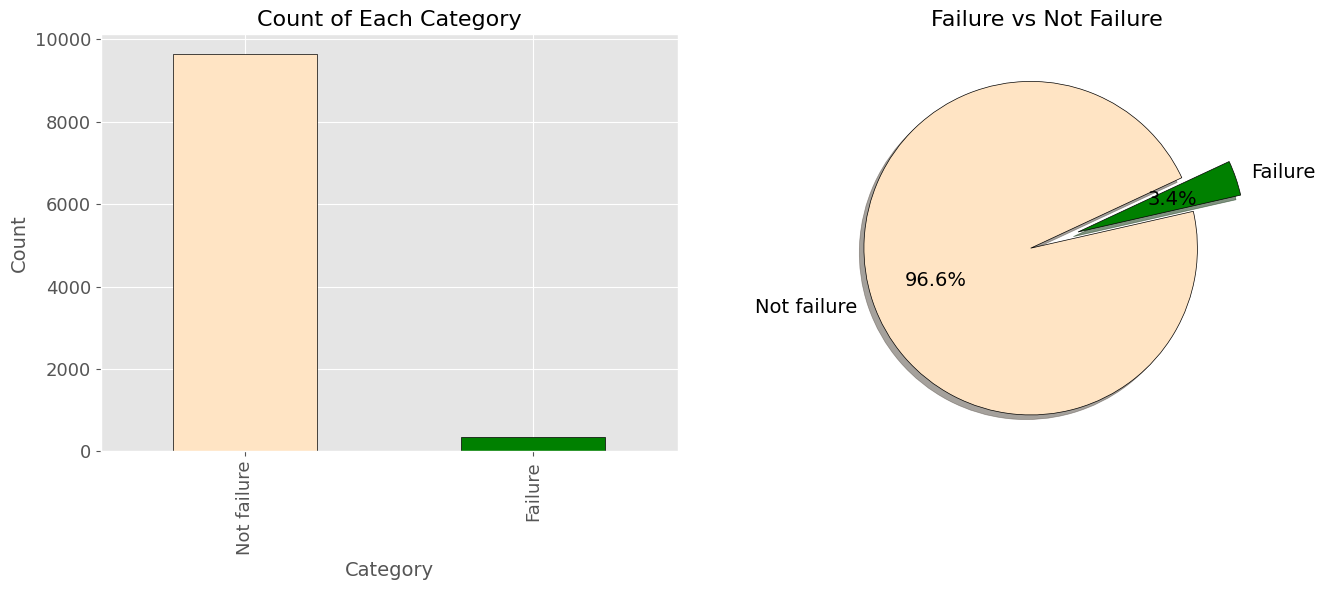

In [15]:
colors = ['bisque', 'green'] 

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[1].pie(
    milling_df['Target'].value_counts(),
    explode=[0.1, 0.2], 
    labels=['Not failure', 'Failure'],
    autopct='%1.1f%%',
    wedgeprops={'edgecolor': 'black'},
    shadow=True,
    startangle=25,
    colors=colors
)
for text in ax[1].texts:
    text.set_fontsize(14)  
ax[1].set_title('Failure vs Not Failure', fontsize=16)  

milling_df['Target'].value_counts().plot(
    kind='bar',
    ax=ax[0],
    color=colors,
    edgecolor='black'
)
ax[0].set_title('Count of Each Category', fontsize=16)  
ax[0].set_xlabel('Category', fontsize=14) 
ax[0].set_ylabel('Count', fontsize=14) 
ax[0].set_xticks([0, 1]) 
ax[0].set_xticklabels(['Not failure', 'Failure'], fontsize=13) 
ax[0].tick_params(axis='both', which='major', labelsize=13)  

plt.tight_layout()
plt.show()

#### Apply Oversampling with SMOTE

In [16]:
smoteomek = SMOTETomek(random_state=42)

X_resampled, y_resampled = smoteomek.fit_resample(X_train, y_train)

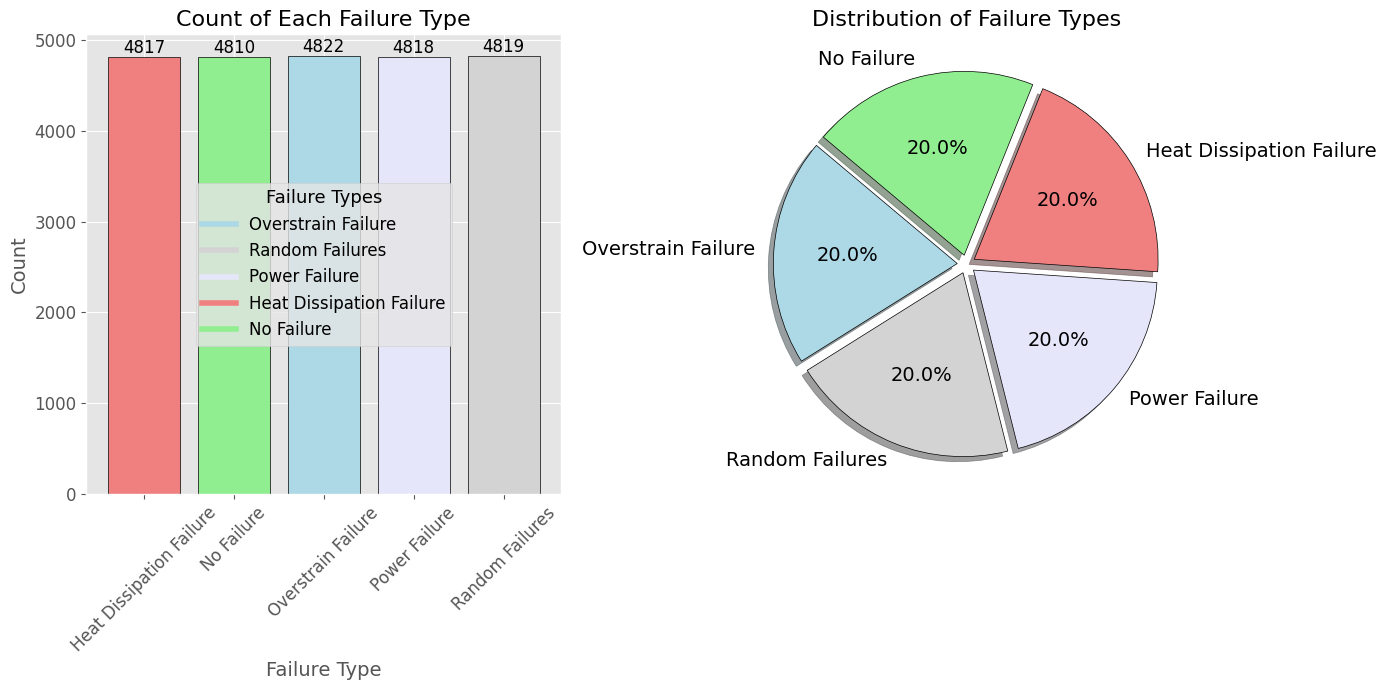

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

label_mapping = {
    0: 'Heat Dissipation Failure',
    1: 'No Failure',
    2: 'Overstrain Failure',
    3: 'Power Failure',
    4: 'Random Failures',
    5: 'Tool Wear Failure'
}

colors = ['#ADD8E6', '#D3D3D3', '#E6E6FA', '#F08080', '#90EE90', '#FFFFE0']

resampled_target_counts = pd.Series(y_resampled).value_counts()

fig, ax = plt.subplots(1, 2, figsize=(14, 7))  

ax[1].pie(
    resampled_target_counts,
    explode=[0.05] * len(resampled_target_counts),  
    labels=[label_mapping[i] for i in resampled_target_counts.index],  
    autopct='%1.1f%%',    
    wedgeprops={'edgecolor': 'black'},
    shadow=True,
    startangle=140,
    colors=colors
)
for text in ax[1].texts:
    text.set_fontsize(14)  
ax[1].set_title('Distribution of Failure Types', fontsize=16) 

bars = ax[0].bar(
    resampled_target_counts.index,
    resampled_target_counts,
    color=colors,
    edgecolor='black'
)

ax[0].legend(
    handles=[plt.Line2D([0], [0], color=color, lw=4) for color in colors],  #
    labels=[label_mapping[i] for i in resampled_target_counts.index],
    title='Failure Types',
    title_fontsize='13',
    fontsize='12',
    loc='center'
)

for bar in bars:
    height = bar.get_height()
    ax[0].text(
        bar.get_x() + bar.get_width() / 2, 
        height,    
        f'{int(height)}',  
        ha='center',   
        va='bottom',  
        fontsize=12  
    )

ax[0].set_title('Count of Each Failure Type', fontsize=16) 
ax[0].set_xlabel('Failure Type', fontsize=14)  
ax[0].set_ylabel('Count', fontsize=14) 
ax[0].set_xticks(resampled_target_counts.index)  
ax[0].set_xticklabels([label_mapping[i] for i in resampled_target_counts.index], fontsize=12, rotation=45)  
ax[0].tick_params(axis='both', which='major', labelsize=12)  

plt.tight_layout()
plt.show()

In [18]:
print("Original training class distribution:")
print(milling_df['Failure Type'].value_counts())

print("\nResampled training class distribution:")
print(pd.Series(y_resampled).value_counts())

X_resampled.shape,y_resampled.shape

Original training class distribution:
Failure Type
1    9652
0     112
3      95
2      78
4      45
Name: count, dtype: int64

Resampled training class distribution:
Failure Type
2    4822
4    4819
3    4818
0    4817
1    4810
Name: count, dtype: int64


((24086, 6), (24086,))

#### Checking for Outliers

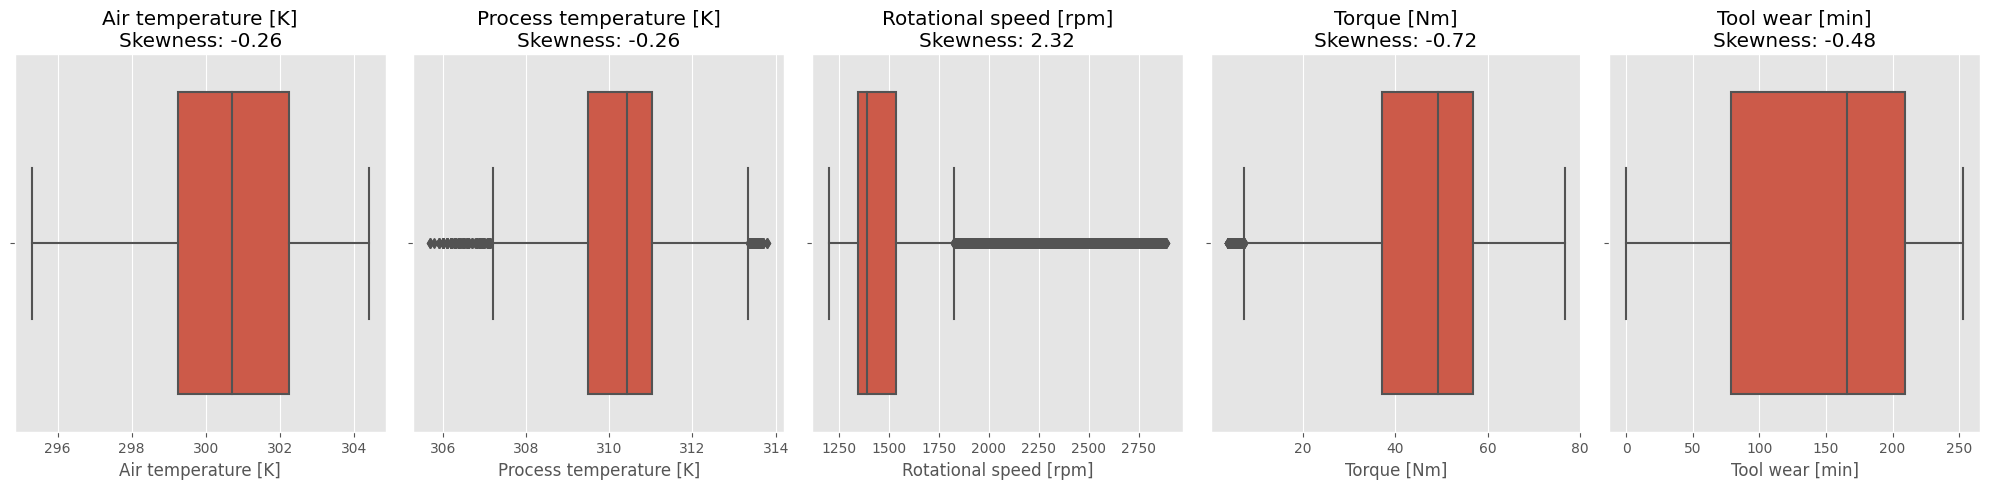

In [19]:
numerical_columns = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, column in enumerate(numerical_columns):
    sns.boxplot(x=X_resampled[column], ax=axes[i])
    skewness = round(X_resampled[column].skew(), 2)
    axes[i].set_title(f'{column}\nSkewness: {skewness}')

plt.tight_layout()
plt.show()

#### Scale the Data

In [20]:
features_with_outliers = ['Rotational speed [rpm]', 'Torque [Nm]']
features_without_outliers = ['Air temperature [K]', 'Process temperature [K]', 'Tool wear [min]', 'Type']

robust_scaler = RobustScaler()
minmax_scaler = MinMaxScaler()

# Apply RobustScaler 
data_with_outliers = X_resampled[features_with_outliers]
scaled_with_robust = robust_scaler.fit_transform(data_with_outliers)

data_with_outliers_test = X_test[features_with_outliers]
scaled_with_robust_test = robust_scaler.transform(data_with_outliers_test)

data_with_outliers_cluster = X_x[features_with_outliers]
scaled_with_robust_cluster = robust_scaler.transform(data_with_outliers_cluster)

# Apply MinMaxScaler 
data_without_outliers = X_resampled[features_without_outliers]
scaled_with_minmax = minmax_scaler.fit_transform(data_without_outliers)

data_without_outliers_test = X_test[features_without_outliers]
scaled_with_minmax_test = minmax_scaler.transform(data_without_outliers_test)

data_without_outliers_cluster = X_x[features_without_outliers]
scaled_with_minmax_cluster = minmax_scaler.transform(data_without_outliers_cluster)

# Ensure indices are aligned during DataFrame creation
scaled_with_robust_df = pd.DataFrame(scaled_with_robust, columns=features_with_outliers, index=X_resampled.index)
scaled_without_minmax_df = pd.DataFrame(scaled_with_minmax, columns=features_without_outliers, index=X_resampled.index)

# Combine scaled data with the remaining columns
X_Scaled = pd.concat([scaled_with_robust_df, scaled_without_minmax_df], axis=1)
#X_Scaled = pd.concat([X_resampled['Type'], scaled_with_robust_df, scaled_without_minmax_df], axis=1)

print("Scaled Training Data (X_Scaled):")
display(X_Scaled.head(5))

# Ensure indices are aligned for the test set as well
scaled_with_robust_df_test = pd.DataFrame(scaled_with_robust_test, columns=features_with_outliers, index=X_test.index)
scaled_without_minmax_df_test = pd.DataFrame(scaled_with_minmax_test, columns=features_without_outliers, index=X_test.index)

X_test_Scaled = pd.concat([scaled_with_robust_df_test, scaled_without_minmax_df_test], axis=1)
#X_test_Scaled = pd.concat([X_test['Type'], scaled_with_robust_df_test, scaled_without_minmax_df_test], axis=1)

print("Scaled Test Data (X_test_Scaled):")
display(X_test_Scaled.head(5))

# Ensure indices are aligned for the test set as well
scaled_with_robust_df_cluster = pd.DataFrame(scaled_with_robust_cluster, columns=features_with_outliers, index=X_x.index)
scaled_without_minmax_df_cluster = pd.DataFrame(scaled_with_minmax_cluster, columns=features_without_outliers, index=X_x.index)

X_cluster_Scaled = pd.concat([scaled_with_robust_df_cluster, scaled_without_minmax_df_cluster], axis=1)

print("Scaled CLuster Data (X_cluster_Scaled):")
display(X_cluster_Scaled.head(5))

Scaled Training Data (X_Scaled):


,Rotational speed [rpm],Torque [Nm],Air temperature [K],Process temperature [K],Tool wear [min],Type
0,0.502591,-0.459324,0.791209,0.580247,0.189723,0.5
1,1.062176,-0.817698,0.384615,0.555556,0.134387,1.0
2,2.585492,-1.342640,0.747253,0.703704,0.766798,0.5
3,1.077720,-0.676368,0.648352,0.641975,0.280632,0.0
4,-0.129534,-0.141331,0.395604,0.518519,0.296443,0.5


Scaled Test Data (X_test_Scaled):


,Rotational speed [rpm],Torque [Nm],Air temperature [K],Process temperature [K],Tool wear [min],Type
1254,0.207254,0.005048,0.241758,0.382716,0.007905,0.0
9948,2.145078,-1.221500,0.318681,0.259259,0.426877,0.5
7062,0.088083,0.090855,0.582418,0.580247,0.620553,1.0
8729,-0.196891,0.227138,0.219780,0.370370,0.359684,0.5
6894,0.093264,-0.151426,0.637363,0.740741,0.533597,0.5


Scaled CLuster Data (X_cluster_Scaled):


,Rotational speed [rpm],Torque [Nm],Air temperature [K],Process temperature [K],Tool wear [min],Type
0,0.834197,-0.328089,0.307692,0.358025,0.000000,1.0
1,0.093264,-0.151426,0.318681,0.370370,0.011858,0.5
2,0.559585,0.005048,0.307692,0.345679,0.019763,0.5
3,0.222798,-0.494657,0.318681,0.358025,0.027668,0.5
4,0.093264,-0.469419,0.318681,0.370370,0.035573,0.5


/tmp/ipykernel_8420/1301253307.py:3: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.scatterplot(data=milling_df, x='Rotational speed [rpm]', y='Torque [Nm]', hue='Failure Type', palette=['#E9C0CB', '#39A692', '#976EBD', '#ACBF5C', '#DF8B4E', '#D3D3D3'], ax=ax[0])


Text(0.5, 1.0, 'Excluding class no failure')

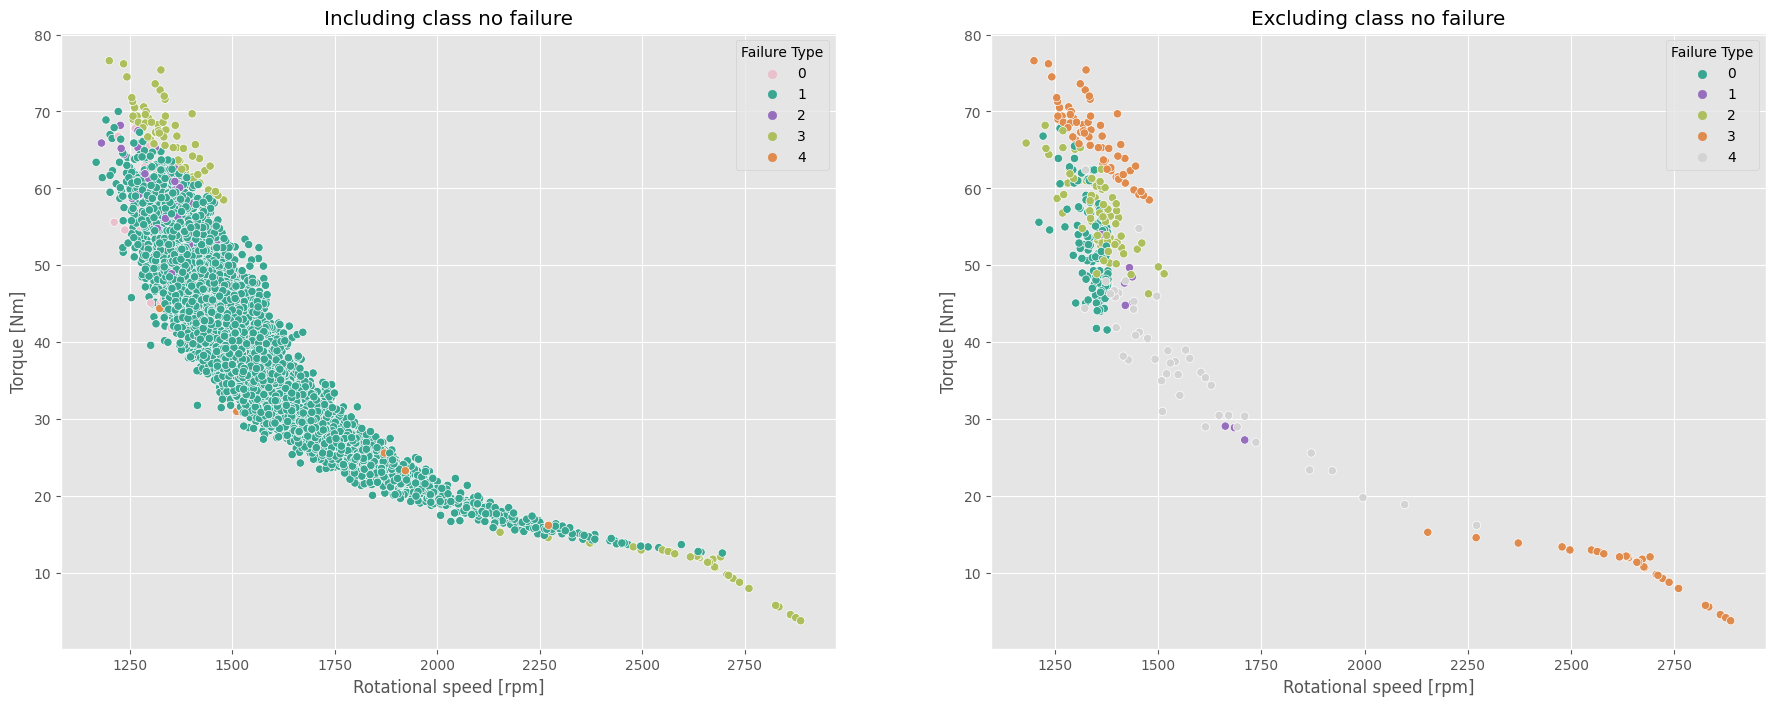

In [21]:
fig, ax = plt.subplots(1,2, figsize=[22,8])
plt.title('Rot. Speed vs Torque wrt Failure Type')
sns.scatterplot(data=milling_df, x='Rotational speed [rpm]', y='Torque [Nm]', hue='Failure Type', palette=['#E9C0CB', '#39A692', '#976EBD', '#ACBF5C', '#DF8B4E', '#D3D3D3'], ax=ax[0])
sns.scatterplot(data=milling_df[milling_df['Target'] == 1], x='Rotational speed [rpm]', y='Torque [Nm]', hue='Failure Type', palette=['#39A692', '#976EBD', '#ACBF5C', '#DF8B4E', '#D3D3D3'], ax=ax[1])

ax[0].set_title('Including class no failure')
ax[1].set_title('Excluding class no failure')

/tmp/ipykernel_8420/51878967.py:3: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.scatterplot(data=milling_df, x='Torque [Nm]', y='Tool wear [min]', hue='Failure Type', palette=['#E9C0CB', '#39A692', '#976EBD', '#ACBF5C', '#DF8B4E', '#D3D3D3'], ax=ax[0])


Text(0.5, 1.0, 'Excluding class no failure')

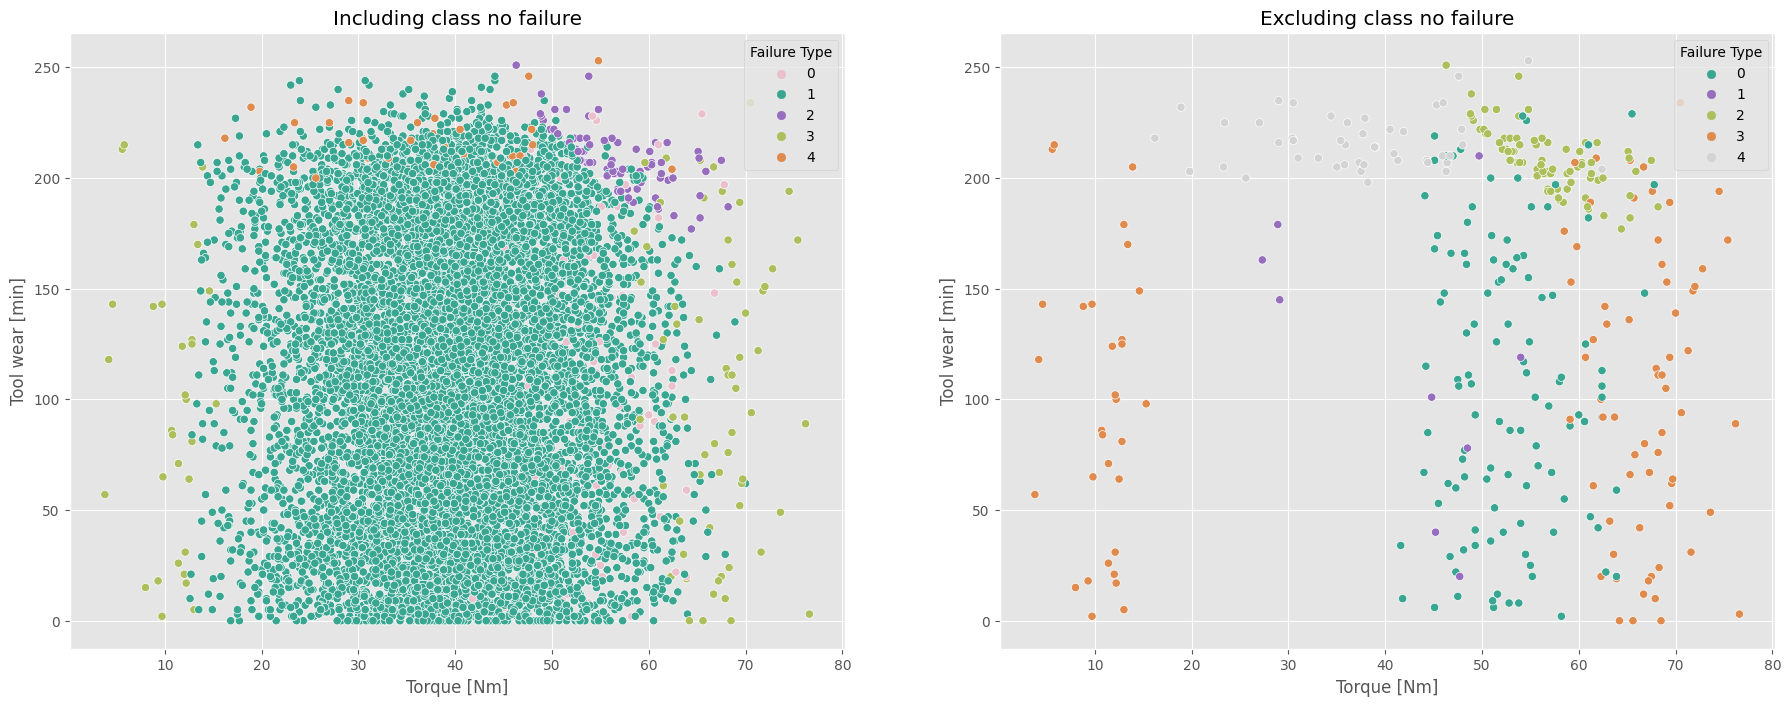

In [22]:
fig, ax = plt.subplots(1,2, figsize=[22,8])
plt.title('Rot. Speed vs Torque wrt Failure Type')
sns.scatterplot(data=milling_df, x='Torque [Nm]', y='Tool wear [min]', hue='Failure Type', palette=['#E9C0CB', '#39A692', '#976EBD', '#ACBF5C', '#DF8B4E', '#D3D3D3'], ax=ax[0])
sns.scatterplot(data=milling_df[milling_df['Target'] == 1], x='Torque [Nm]', y='Tool wear [min]', hue='Failure Type', palette=['#39A692', '#976EBD', '#ACBF5C', '#DF8B4E', '#D3D3D3'], ax=ax[1])

ax[0].set_title('Including class no failure')
ax[1].set_title('Excluding class no failure')

/tmp/ipykernel_8420/1711503842.py:3: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.scatterplot(data=milling_df, x='Air temperature [K]', y='Torque [Nm]', hue='Failure Type', palette=['#E9C0CB', '#39A692', '#976EBD', '#ACBF5C', '#DF8B4E', '#D3D3D3'], ax=ax[0])


Text(0.5, 1.0, 'Excluding class no failure')

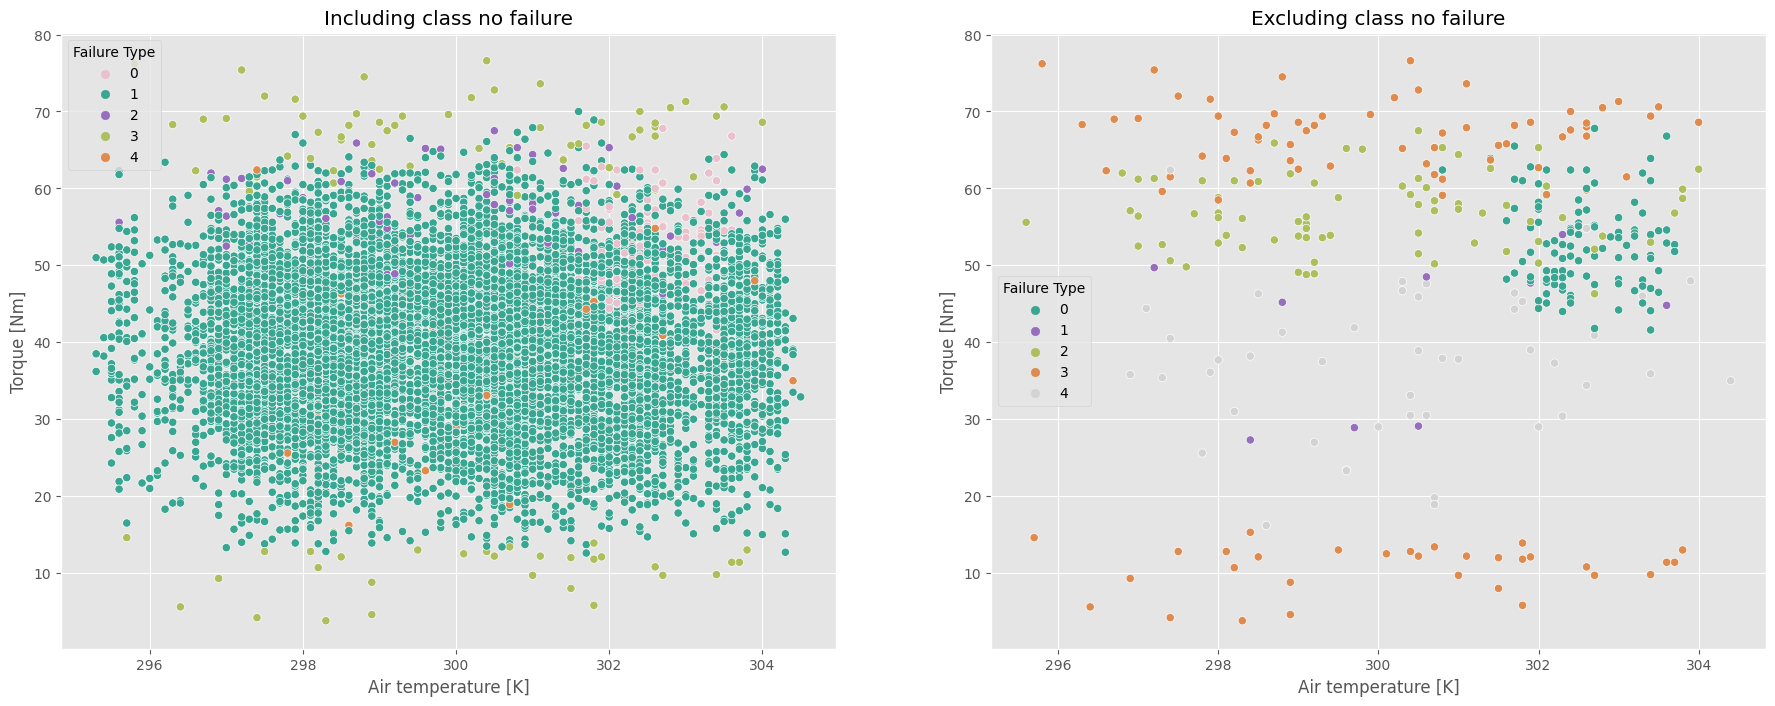

In [23]:
fig, ax = plt.subplots(1,2, figsize=[22,8])
plt.title('Rot. Speed vs Torque wrt Failure Type')
sns.scatterplot(data=milling_df, x='Air temperature [K]', y='Torque [Nm]', hue='Failure Type', palette=['#E9C0CB', '#39A692', '#976EBD', '#ACBF5C', '#DF8B4E', '#D3D3D3'], ax=ax[0])
sns.scatterplot(data=milling_df[milling_df['Target'] == 1], x='Air temperature [K]', y='Torque [Nm]', hue='Failure Type', palette=['#39A692', '#976EBD', '#ACBF5C', '#DF8B4E', '#D3D3D3'], ax=ax[1])

ax[0].set_title('Including class no failure')
ax[1].set_title('Excluding class no failure')

#### Store Datasets

In [24]:
%store X_train
%store y_train 

%store X_test
%store y_test

%store X_resampled
%store y_resampled

%store X_Scaled
%store X_test_Scaled

%store milling_df

%store X_cluster_Scaled
%store X_x
%store y

Stored 'X_train' (DataFrame)
Stored 'y_train' (Series)
Stored 'X_test' (DataFrame)
Stored 'y_test' (Series)
Stored 'X_resampled' (DataFrame)
Stored 'y_resampled' (Series)
Stored 'X_Scaled' (DataFrame)
Stored 'X_test_Scaled' (DataFrame)
Stored 'milling_df' (DataFrame)
Stored 'X_cluster_Scaled' (DataFrame)
Stored 'X_x' (DataFrame)
Stored 'y' (Series)
